#📌 Extracão

In [1]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json"

# Fazendo a requisição à API (GitHub)
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    # Convertendo para DataFrame
    df = pd.DataFrame(data)
    print("Dados importados com sucesso!")
else:
    print(f"Erro ao acessar a API: {response.status_code}")

Dados importados com sucesso!


#🔧 Transformação

In [2]:
# Exemplo de como tratar o aninhamento e a conversão de tipos
df_flat = pd.json_normalize(data) # Achata a estrutura do JSON

# Convertendo a coluna Total para numérico, tratando erros como NaN
df_flat['account.Charges.Total'] = pd.to_numeric(df_flat['account.Charges.Total'], errors='coerce')

# Verificando se restaram valores nulos após a conversão
print(df_flat.isnull().sum())

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [3]:
# 1. Garantir que a coluna de cobrança mensal seja numérica (float)
df_flat['account.Charges.Monthly'] = pd.to_numeric(df_flat['account.Charges.Monthly'], errors='coerce')

# 2. Criar a coluna Contas_Diarias
# Dividimos o valor mensal por 30 (dias padrão) e arredondamos para 2 casas decimais
df_flat['Contas_Diarias'] = (df_flat['account.Charges.Monthly'] / 30).round(2)

# 3. Visualizar as primeiras linhas para validar a nova métrica
print(df_flat[['customerID', 'account.Charges.Monthly', 'Contas_Diarias']].head())

# Opcional: Verificar se o cálculo gerou algum valor nulo inesperado
print(f"\nValores nulos em Contas_Diarias: {df_flat['Contas_Diarias'].isnull().sum()}")

   customerID  account.Charges.Monthly  Contas_Diarias
0  0002-ORFBO                     65.6            2.19
1  0003-MKNFE                     59.9            2.00
2  0004-TLHLJ                     73.9            2.46
3  0011-IGKFF                     98.0            3.27
4  0013-EXCHZ                     83.9            2.80

Valores nulos em Contas_Diarias: 0


In [4]:
# 1. Dicionário de tradução para as colunas principais
traduçao_colunas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasao',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Parceiro',
    'customer.Dependents': 'Dependentes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Serviço_Telefonico',
    'internet.InternetService': 'Tipo_Internet',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Fatura_Digital',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Valor_Mensal',
    'account.Charges.Total': 'Valor_Total',
    'Contas_Diarias': 'Custo_Diario'
}

# Renomeando as colunas
df_telecom = df_flat.rename(columns=traduçao_colunas)

# 2. Transformação Binária (Mapeamento)
# Convertendo 'Yes'/'No' para 1/0 para facilitar cálculos de taxa de evasão
mapa_binario = {'Yes': 1, 'No': 0, 'Female': 'Feminino', 'Male': 'Masculino'}

colunas_para_mapear = ['Evasao', 'Parceiro', 'Dependentes', 'Serviço_Telefonico', 'Fatura_Digital']

for col in colunas_para_mapear:
    if col in df_telecom.columns:
        df_telecom[col] = df_telecom[col].map({'Yes': 1, 'No': 0})

# Ajustando o gênero para português
df_telecom['Genero'] = df_telecom['Genero'].map({'Female': 'Feminino', 'Male': 'Masculino'})

# 3. Visualizando o resultado final da padronização
print("Colunas traduzidas e dados padronizados:")
print(df_telecom[['ID_Cliente', 'Genero', 'Evasao', 'Custo_Diario']].head())

Colunas traduzidas e dados padronizados:
   ID_Cliente     Genero  Evasao  Custo_Diario
0  0002-ORFBO   Feminino     0.0          2.19
1  0003-MKNFE  Masculino     0.0          2.00
2  0004-TLHLJ  Masculino     1.0          2.46
3  0011-IGKFF  Masculino     1.0          3.27
4  0013-EXCHZ   Feminino     1.0          2.80


#📊 Carga e análise

In [5]:
# Selecionando apenas as colunas numéricas de interesse
colunas_numericas = ['Meses_Contrato', 'Valor_Mensal', 'Custo_Diario', 'Valor_Total']

# Gerando a tabela estatística
analise_estatistica = df_telecom[colunas_numericas].describe().T

# Adicionando a Mediana, que não vem no describe padrão
analise_estatistica['median'] = df_telecom[colunas_numericas].median()

# Reorganizando para facilitar a leitura
analise_estatistica = analise_estatistica[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

print("Resumo Estatístico dos Clientes:")
print(analise_estatistica.round(2))

Resumo Estatístico dos Clientes:
                   mean   median      std    min     25%      50%      75%  \
Meses_Contrato    32.35    29.00    24.57   0.00    9.00    29.00    55.00   
Valor_Mensal      64.72    70.30    30.13  18.25   35.42    70.30    89.88   
Custo_Diario       2.16     2.34     1.00   0.61    1.18     2.34     3.00   
Valor_Total     2280.63  1391.00  2268.63  18.80  400.22  1391.00  3785.30   

                    max  
Meses_Contrato    72.00  
Valor_Mensal     118.75  
Custo_Diario       3.96  
Valor_Total     8684.80  


In [6]:
# Taxa Geral de Evasão (Churn Rate)
taxa_evasao = df_telecom['Evasao'].mean() * 100
print(f"\nTaxa Geral de Evasão: {taxa_evasao:.2f}%")

# Verificando a distribuição de Idosos na base
print("\nDistribuição de Idosos (0=Não, 1=Sim):")
print(df_telecom['Idoso'].value_counts(normalize=True).round(2) * 100)


Taxa Geral de Evasão: 26.54%

Distribuição de Idosos (0=Não, 1=Sim):
Idoso
0    84.0
1    16.0
Name: proportion, dtype: float64


/tmp/ipykernel_578/3094828755.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Evasao', data=df_telecom, palette='viridis')


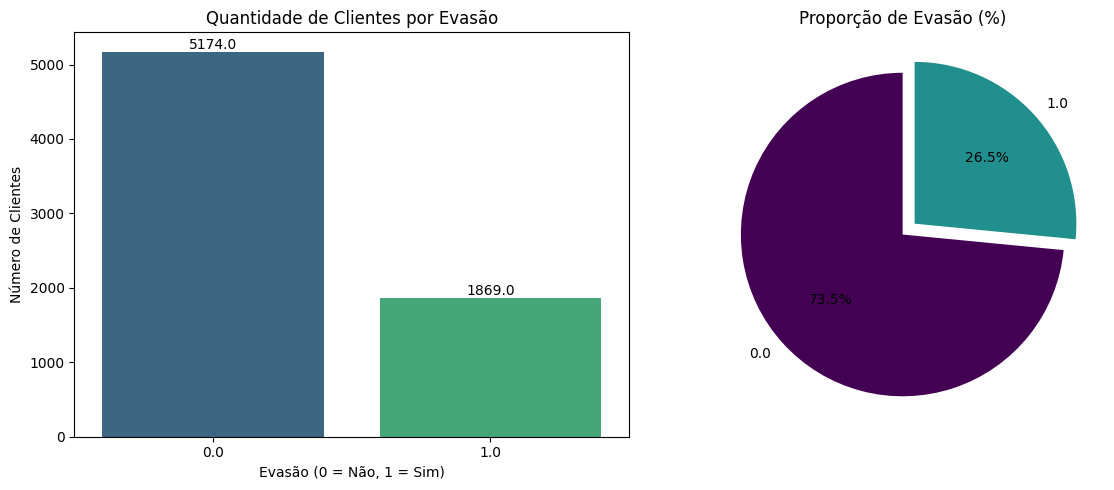

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a área de plotagem
plt.figure(figsize=(12, 5))

# 1. Gráfico de Barras (Frequência)
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Evasao', data=df_telecom, palette='viridis')
plt.title('Quantidade de Clientes por Evasão')
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Número de Clientes')

# Adicionando rótulos de dados nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de Pizza (Proporção)
plt.subplot(1, 2, 2)
df_telecom['Evasao'].value_counts().plot.pie(autopct='%.1f%%', startangle=90, colors=['#440154', '#218F8D'], explode=[0, 0.1])
plt.title('Proporção de Evasão (%)')
plt.ylabel('') # Remove o label lateral

plt.tight_layout()
plt.show()

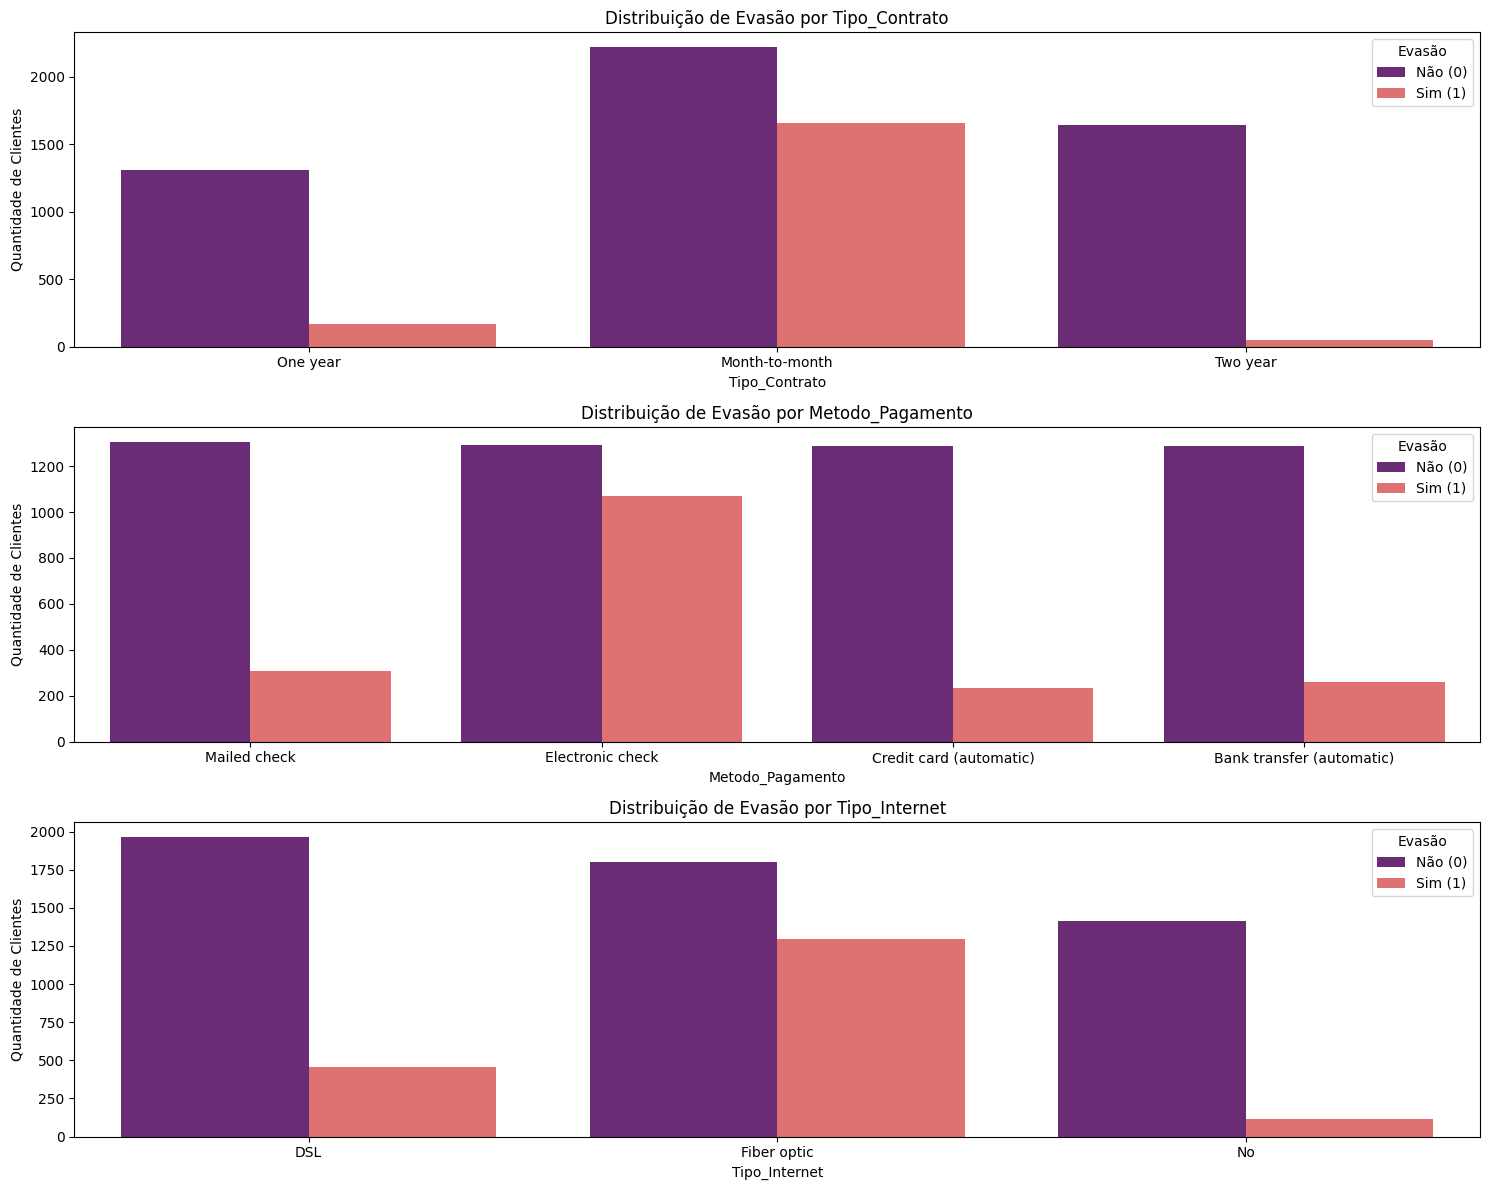

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variáveis para análise
variaveis_cat = ['Tipo_Contrato', 'Metodo_Pagamento', 'Tipo_Internet']

plt.figure(figsize=(15, 12))

for i, col in enumerate(variaveis_cat):
    plt.subplot(3, 1, i+1)

    # Criando um gráfico de contagem com a separação por Evasão
    ax = sns.countplot(x=col, hue='Evasao', data=df_telecom, palette='magma')

    plt.title(f'Distribuição de Evasão por {col}')
    plt.xlabel(col)
    plt.ylabel('Quantidade de Clientes')
    plt.legend(title='Evasão', labels=['Não (0)', 'Sim (1)'])

plt.tight_layout()
plt.show()

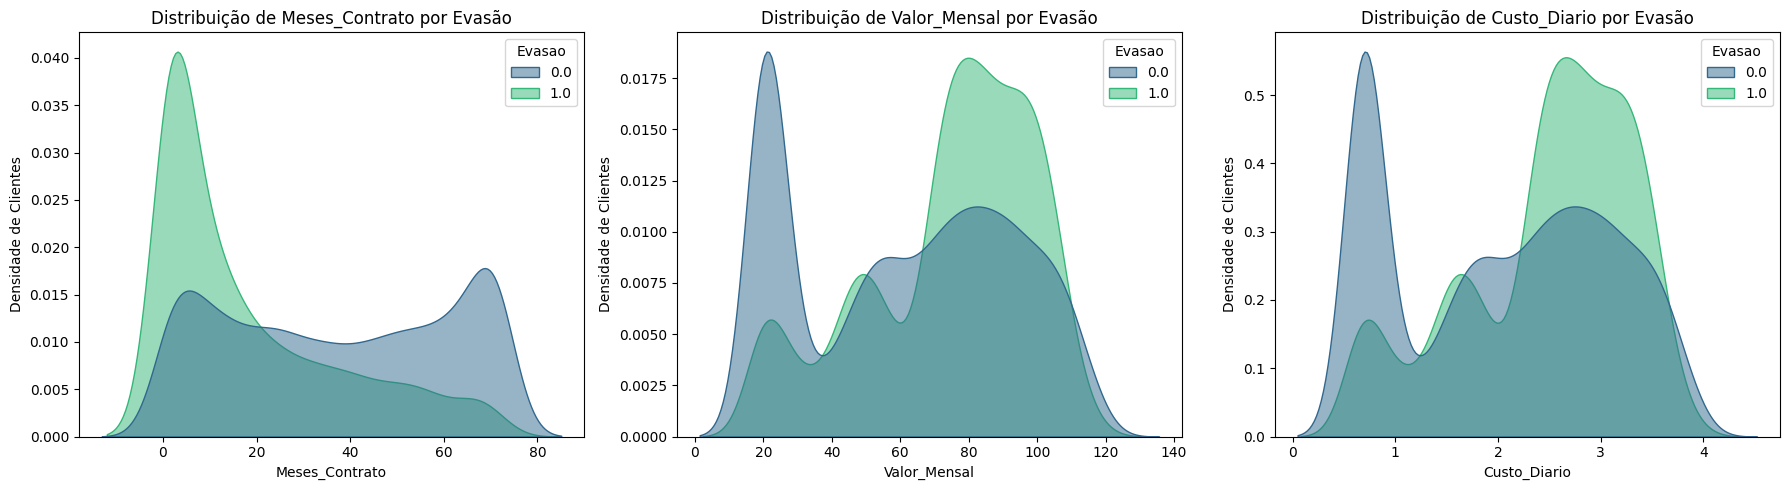

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo as variáveis numéricas para análise
colunas_num = ['Meses_Contrato', 'Valor_Mensal', 'Custo_Diario']

plt.figure(figsize=(18, 5))

for i, col in enumerate(colunas_num):
    plt.subplot(1, 3, i+1)
    # KDE plot mostra a "massa" de clientes ao longo dos valores
    sns.kdeplot(data=df_telecom, x=col, hue='Evasao', fill=True, common_norm=False, palette='viridis', alpha=0.5)
    plt.title(f'Distribuição de {col} por Evasão')
    plt.xlabel(col)
    plt.ylabel('Densidade de Clientes')

plt.tight_layout()
plt.show()

#📄Relatorio Final

1. Introdução
O objetivo deste projeto foi analisar a base de dados de clientes da Telecom X para identificar os principais fatores que levam ao Churn (cancelamento de serviços). A evasão de clientes é um dos maiores desafios do setor de telecomunicações, impactando diretamente a receita e aumentando os custos de aquisição de novos usuários. Esta análise servirá como base para que a equipe de Data Science desenvolva modelos preditivos e para que o time de Customer Success crie estratégias de retenção.

2. Limpeza e Tratamento de Dados (ETL)
Para garantir a confiabilidade das análises, realizamos um processo rigoroso de ETL:

Extração: Os dados foram consumidos diretamente de uma API (GitHub) no formato JSON.

Normalização: Como o JSON era aninhado, utilizamos pd.json_normalize para achatar as colunas de perfil, serviços e conta.

Tipagem: Convertemos colunas financeiras (como Valor_Total) de texto para numérico e tratamos valores ausentes (NaN).

Tradução e Padronização: Renomeamos as colunas para o português e mapeamos variáveis categóricas ("Yes"/"No") para valores binários (1/0), facilitando o processamento estatístico.

Feature Engineering: Criamos a métrica "Custo_Diario", dividindo o faturamento mensal por 30, para entender o peso diário do serviço no bolso do cliente.

3. Análise Exploratória de Dados (EDA)
Durante a exploração, identificamos padrões críticos através de visualizações:

A. Perfil Geral de Evasão
Visualizamos que a taxa de churn da empresa está em torno de 26,5%. Embora a maioria dos clientes permaneça, a perda de 1/4 da base é um sinal de alerta.

B. Impacto do Tipo de Contrato e Pagamento
Contratos: Clientes com contratos "Mês a mês" apresentam uma taxa de evasão drasticamente superior aos de contrato anual ou bianual.

Pagamento: O método de "Cheque Eletrônico" está fortemente correlacionado com o churn, sugerindo fricção no processo de pagamento ou perfil de cliente mais volátil.

C. Comportamento Financeiro e Tempo de Casa
Tenure (Meses de Contrato): A maior concentração de cancelamentos ocorre nos primeiros 6 meses. Clientes que superam a barreira de 1 ano tendem a se tornar fiéis.

Valor Mensal: Clientes que evadem tendem a ter faturas mensais mais altas (acima de R$ 70,00), indicando que o preço é um fator determinante para a saída.

4. Conclusões e Insights
A "Crise dos Primeiros Meses": A Telecom X perde muitos clientes logo no início da jornada. Isso sugere problemas na instalação, expectativa vs. realidade ou onboarding ineficiente.

Sensibilidade ao Preço: Clientes com faturas mais elevadas não percebem valor suficiente para manter o serviço, buscando alternativas mais baratas no mercado.

Fidelização por Contrato: O modelo de contrato mensal é a principal porta de saída. A migração para planos anuais é a forma mais eficaz de retenção.

5. Recomendações Estratégicas
Com base nos dados, sugerimos as seguintes ações para a Telecom X:

Programa de Boas-Vindas: Criar uma régua de comunicação e suporte prioritário para clientes nos primeiros 90 dias (período de maior risco).

Incentivo à Fidelização: Oferecer descontos progressivos ou benefícios exclusivos para clientes que migrarem do plano "Mês a mês" para o "Anual".

Revisão do Pagamento: Investigar falhas no processo de "Cheque Eletrônico" ou oferecer bônus para clientes que cadastrarem o débito automático/cartão de crédito.

Plano de Retenção para High-Ticket: Monitorar clientes com contas diárias acima da média e oferecer upgrades de serviço ou descontos preventivos antes que eles entrem em zona de cancelamento.

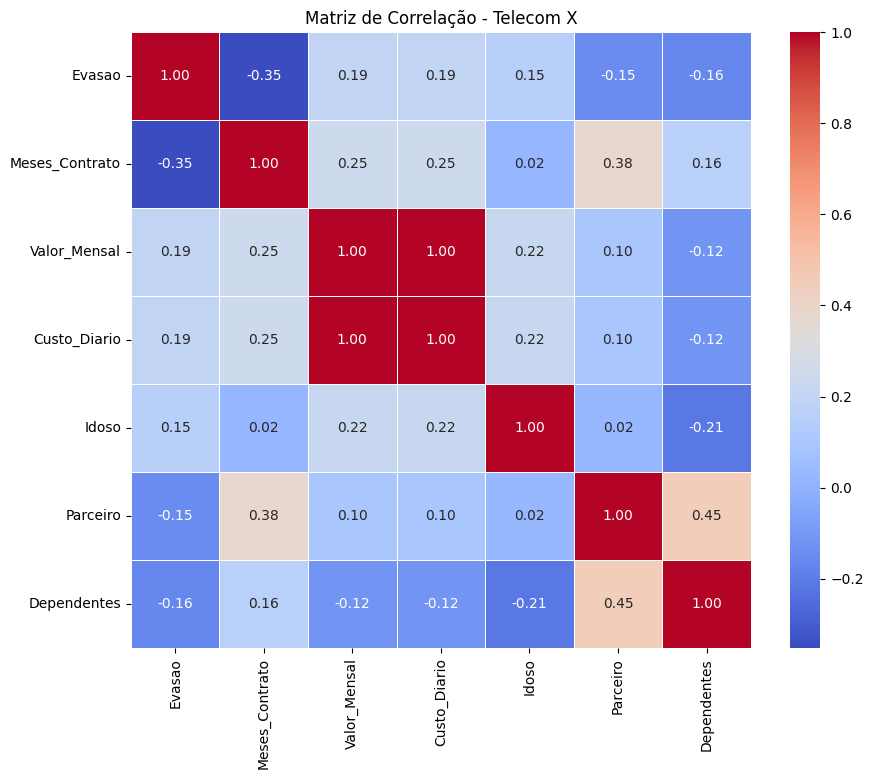

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando colunas numéricas e as que transformamos em binárias
colunas_correlacao = [
    'Evasao', 'Meses_Contrato', 'Valor_Mensal',
    'Custo_Diario', 'Idoso', 'Parceiro', 'Dependentes'
]

# Calculando a matriz de correlação (Pearson)
matriz_corr = df_telecom[colunas_correlacao].corr()

# Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação - Telecom X')
plt.show()

/tmp/ipykernel_578/4269435062.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Servicos', y='Evasao', data=df_telecom, palette='Blues_d')


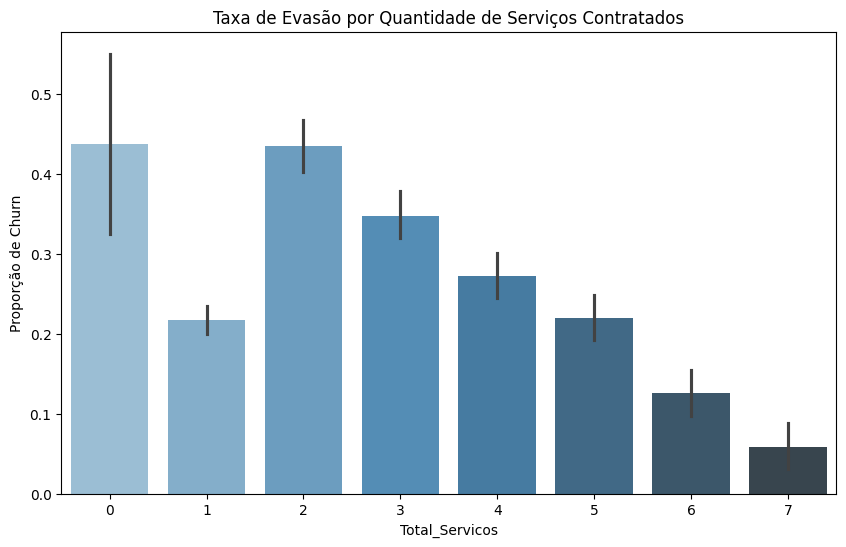

In [11]:
# Lista de colunas de serviços (precisam estar no formato original ou mapeadas)
servicos = [
    'phone.PhoneService', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
    'internet.StreamingMovies'
]

# Criando a contagem de serviços (Somando onde o valor é 'Yes')
# Nota: use o df original ou ajuste para o mapeamento binário que fizemos
df_telecom['Total_Servicos'] = df_flat[servicos].apply(lambda x: x.str.contains('Yes')).sum(axis=1)

# Visualizando a relação entre Total de Serviços e a Taxa de Evasão
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Servicos', y='Evasao', data=df_telecom, palette='Blues_d')
plt.title('Taxa de Evasão por Quantidade de Serviços Contratados')
plt.ylabel('Proporção de Churn')
plt.show()

# PARTE DOIS

## EXTRAÇÃO DE DADOS

In [12]:
df.to_csv("dados_tratados.csv", index=False)

In [13]:
import pandas as pd
import ast

# 1. Carregar os dados
df = pd.read_csv('dados_tratados.csv')

# 2. Descarte do identificador único (Conforme sua orientação estratégica)
# O ID do cliente não ajuda o modelo a encontrar padrões, apenas causa ruído.
df.drop(columns=['customerID'], inplace=True)

# 3. Tratamento das colunas complexas (Transformando strings de dicionários em colunas)
# Nota: Como o CSV salvou dicionários como strings, precisamos "achatar" novamente
def expand_dict_column(df, column_name):
    # Converte string de dicionário para dicionário real e cria novas colunas
    new_cols = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x).apply(pd.Series)
    return pd.concat([df.drop(column_name, axis=1), new_cols], axis=1)

# Aplicando a expansão nas colunas aninhadas
for col in ['customer', 'phone', 'internet', 'account']:
    df = expand_dict_column(df, col)

# 4. Tratamento final de tipos (Charges/Total cost)
# O campo Charges (Monthly e Total) pode vir aninhado. Vamos garantir que sejam floats.
if 'Charges' in df.columns:
    charges_df = df['Charges'].apply(pd.Series)
    df = pd.concat([df.drop('Charges', axis=1), charges_df], axis=1)

df['Total'] = pd.to_numeric(df['Total'], errors='coerce').fillna(0)

print(f"Dados prontos! Colunas atuais: {df.columns.tolist()}")
print(f"Formato do dataset: {df.shape}")

Dados prontos! Colunas atuais: ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']
Formato do dataset: (7267, 20)


In [14]:
## ENCODING

In [15]:
import pandas as pd

# 1. Identificar colunas categóricas (object)
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

# 2. Aplicar One-Hot Encoding
# Isso transformará, por exemplo, 'Tipo_Contrato' em 'Tipo_Contrato_One year' e 'Tipo_Contrato_Two year'
df_ml = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

# 3. Garantir que o Churn (nossa variável alvo) seja 0 ou 1
# Caso ela ainda esteja como Yes/No após o encoding manual:
if 'Churn_Yes' in df_ml.columns:
    df_ml.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

print("Exemplo de colunas após o Encoding:")
print(df_ml.head())

Exemplo de colunas após o Encoding:
   SeniorCitizen  tenure  Monthly    Total  Churn  gender_Male  Partner_Yes  \
0              0       9     65.6   593.30  False        False         True   
1              0       9     59.9   542.40  False         True        False   
2              0       4     73.9   280.85   True         True        False   
3              1      13     98.0  1237.85   True         True         True   
4              1       3     83.9   267.40   True        False         True   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  ...  \
0            True              True                           False  ...   
1           False              True                           False  ...   
2           False              True                           False  ...   
3           False              True                           False  ...   
4           False              True                           False  ...   

   StreamingTV_No internet servi

## Verificação da Proporção de Evasão

In [16]:
# Contagem absoluta
contagem = df_ml['Churn'].value_counts()

# Proporção percentual
proporcao = df_ml['Churn'].value_counts(normalize=True) * 100

print("Distribuição de Clientes:")
print(f"Ativos (0): {contagem[0]} ({proporcao[0]:.2f}%)")
print(f"Evasão (1): {contagem[1]} ({proporcao[1]:.2f}%)")

Distribuição de Clientes:
Ativos (0): 5398 (74.28%)
Evasão (1): 1869 (25.72%)


/tmp/ipykernel_578/1716299150.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Ativos (0): {contagem[0]} ({proporcao[0]:.2f}%)")
/tmp/ipykernel_578/1716299150.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Evasão (1): {contagem[1]} ({proporcao[1]:.2f}%)")


## Balanceamento de Classes

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Separando as features (X) do alvo (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 2. Divisão treino e teste (essencial fazer antes do SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Aplicando o SMOTE nos dados de TREINO
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Verificando o novo equilíbrio
print(f"Antes do SMOTE (Treino): {y_train.value_counts()}")
print(f"Após o SMOTE (Treino): {y_train_res.value_counts()}")

Antes do SMOTE (Treino): Churn
False    3778
True     1308
Name: count, dtype: int64
Após o SMOTE (Treino): Churn
False    3778
True     3778
Name: count, dtype: int64


## Padronização

In [18]:
from sklearn.preprocessing import StandardScaler

# Criando o escalonador
scaler = StandardScaler()

# Ajustamos e transformamos APENAS os dados de treino para evitar data leakage
# O SMOTE já deve ter sido aplicado ou será aplicado sobre dados escalonados
X_train_scaled = scaler.fit_transform(X_train_res)

# Transformamos os dados de teste usando a média/desvio do treino
X_test_scaled = scaler.transform(X_test)

## Análise de Correlação

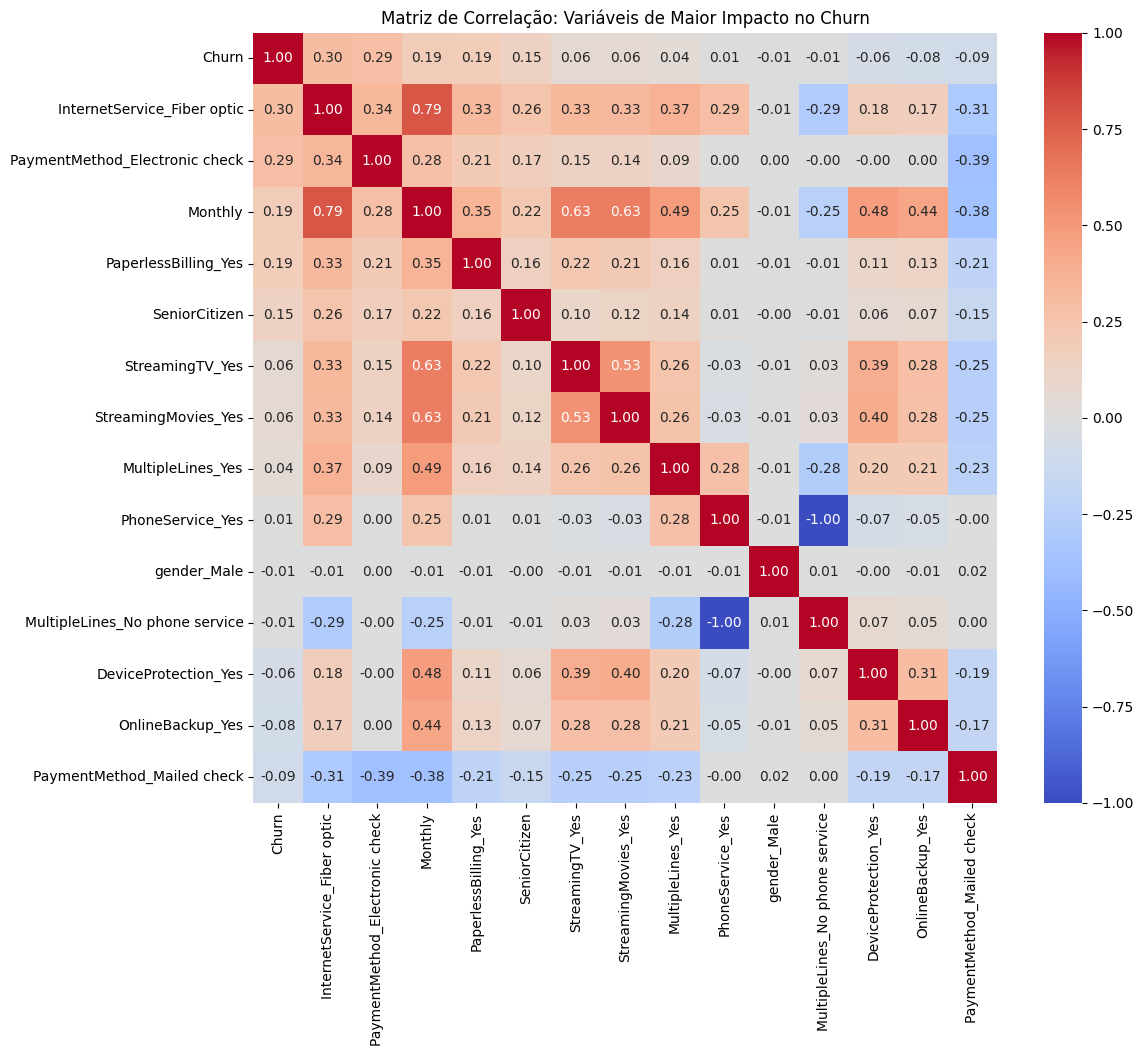

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a correlação de Pearson para o dataset transformado
# Focaremos nas variáveis que mais se relacionam com o Churn
plt.figure(figsize=(12, 10))
correlacao_churn = df_ml.corr()['Churn'].sort_values(ascending=False)

# Criando o Heatmap para visualização das top variáveis
top_correlacoes = df_ml[correlacao_churn.index[:15]].corr() # Top 15 variáveis correlacionadas
sns.heatmap(top_correlacoes, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Matriz de Correlação: Variáveis de Maior Impacto no Churn')
plt.show()

## Análises Direcionadas

/tmp/ipykernel_578/2319415407.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')


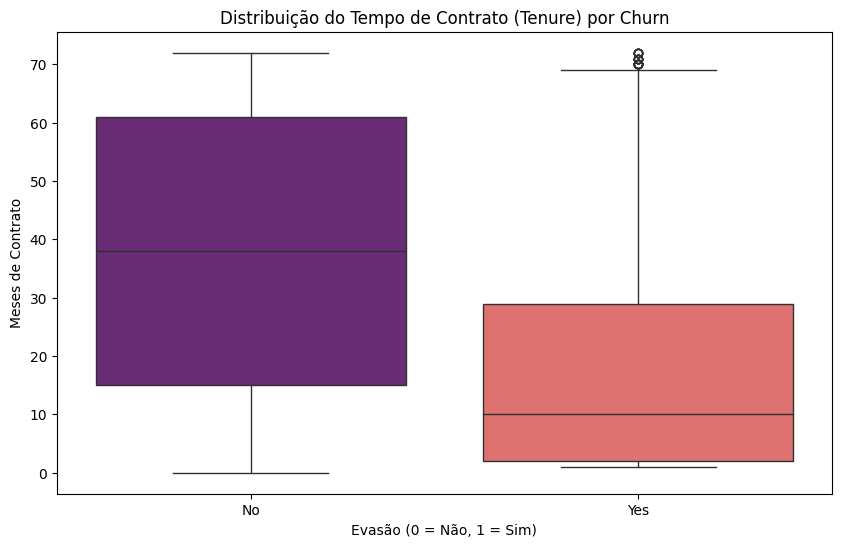

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')
plt.title('Distribuição do Tempo de Contrato (Tenure) por Churn')
plt.xlabel('Evasão (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

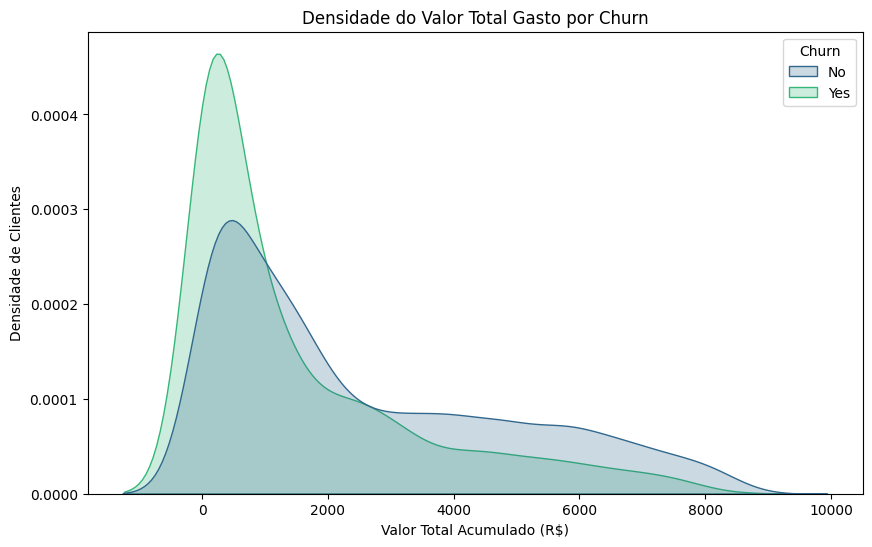

In [21]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Total', hue='Churn', fill=True, common_norm=False, palette='viridis')
plt.title('Densidade do Valor Total Gasto por Churn')
plt.xlabel('Valor Total Acumulado (R$)')
plt.ylabel('Densidade de Clientes')
plt.show()

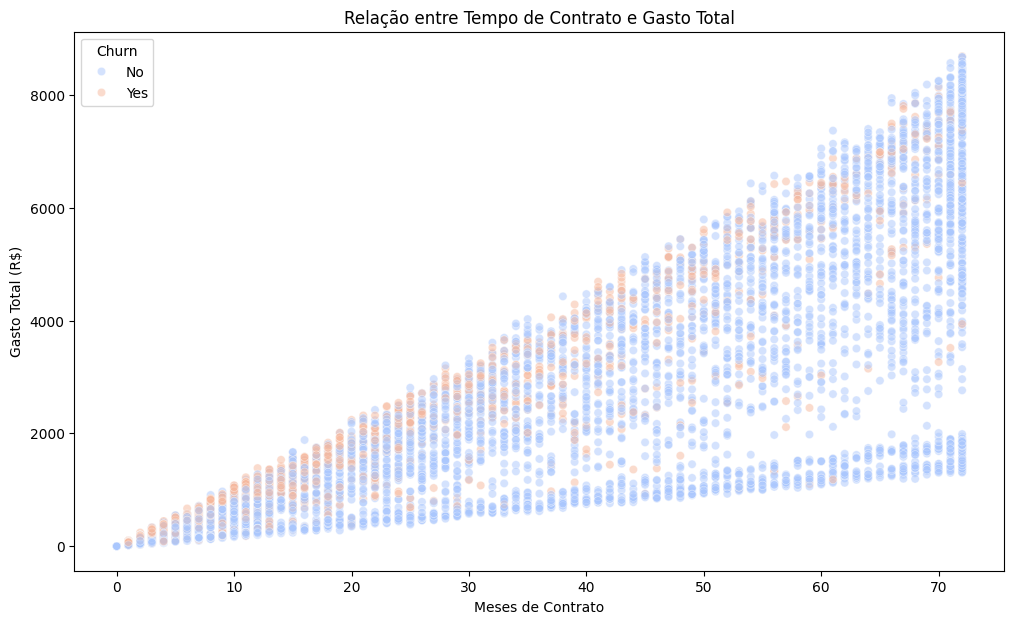

In [22]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='tenure', y='Total', hue='Churn', data=df, alpha=0.5, palette='coolwarm')
plt.title('Relação entre Tempo de Contrato e Gasto Total')
plt.xlabel('Meses de Contrato')
plt.ylabel('Gasto Total (R$)')
plt.show()

## Separação de Dados

In [23]:
from sklearn.model_selection import train_test_split

# 1. Definindo as variáveis explicativas (X) e a variável alvo (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 2. Realizando a divisão (70% Treino, 30% Teste)
# random_state=42 garante que os resultados sejam reproduzíveis
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Base de Treino: {X_train.shape[0]} amostras")
print(f"Base de Teste: {X_test.shape[0]} amostras")
print(f"Proporção de Churn no Treino: {y_train.mean():.2%}")
print(f"Proporção de Churn no Teste: {y_test.mean():.2%}")

Base de Treino: 5086 amostras
Base de Teste: 2181 amostras
Proporção de Churn no Treino: 25.72%
Proporção de Churn no Teste: 25.72%


## Criação de Modelos

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# --- Preparação para o Modelo A (Regressão Logística) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res) # Dados balanceados e escalonados
X_test_scaled = scaler.transform(X_test)

# Treino do Modelo A
modelo_log = LogisticRegression(random_state=42)
modelo_log.fit(X_train_scaled, y_train_res)

# --- Preparação para o Modelo B (Random Forest) ---
# Usamos os dados brutos (X_train_res) sem escalonamento
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_res, y_train_res)

# --- Previsões ---
y_pred_log = modelo_log.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

## Avaliação dos Modelos


  AVALIAÇÃO: Regressão Logística
Acurácia  : 0.7744
Precisão  : 0.5537
Recall    : 0.6346
F1-Score  : 0.5914

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.87      0.82      0.84      1620
        True       0.55      0.63      0.59       561

    accuracy                           0.77      2181
   macro avg       0.71      0.73      0.72      2181
weighted avg       0.79      0.77      0.78      2181



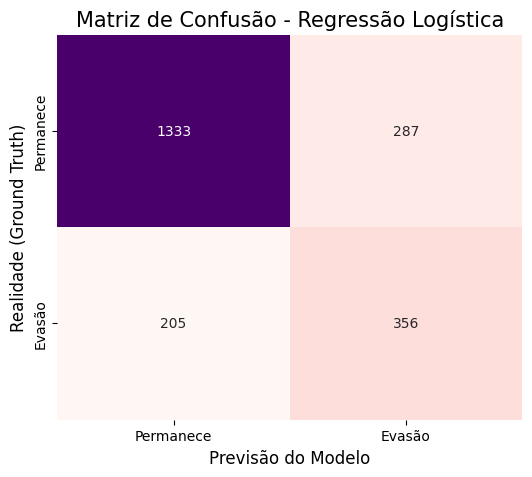


  AVALIAÇÃO: Random Forest
Acurácia  : 0.7740
Precisão  : 0.5630
Recall    : 0.5419
F1-Score  : 0.5522

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.84      0.85      0.85      1620
        True       0.56      0.54      0.55       561

    accuracy                           0.77      2181
   macro avg       0.70      0.70      0.70      2181
weighted avg       0.77      0.77      0.77      2181



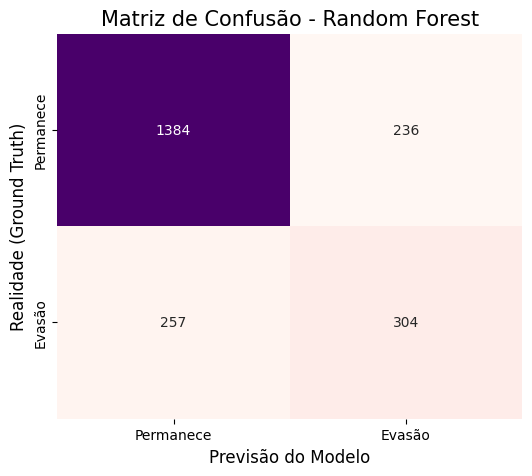

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def avaliar_modelo(nome, y_real, y_pred):
    print(f"\n" + "="*30)
    print(f"  AVALIAÇÃO: {nome}")
    print("="*30)

    # Cálculo das métricas
    metricas = {
        "Acurácia": accuracy_score(y_real, y_pred),
        "Precisão": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1-Score": f1_score(y_real, y_pred)
    }

    for k, v in metricas.items():
        print(f"{k:10}: {v:.4f}")

    print("\nRelatório de Classificação:")
    print(classification_report(y_real, y_pred))

    # Plotando a Matriz de Confusão
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=False,
                xticklabels=['Permanece', 'Evasão'],
                yticklabels=['Permanece', 'Evasão'])
    plt.title(f'Matriz de Confusão - {nome}', fontsize=15)
    plt.ylabel('Realidade (Ground Truth)', fontsize=12)
    plt.xlabel('Previsão do Modelo', fontsize=12)
    plt.show()

# Chamada para os modelos (certifique-se de que y_pred_log e y_pred_rf já foram gerados)
avaliar_modelo("Regressão Logística", y_test, y_pred_log)
avaliar_modelo("Random Forest", y_test, y_pred_rf)

## Análise de Importância das Variáveis

/tmp/ipykernel_578/520314761.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variável', data=pd.concat([coeficientes.head(5), coeficientes.tail(5)]), palette='vlag')


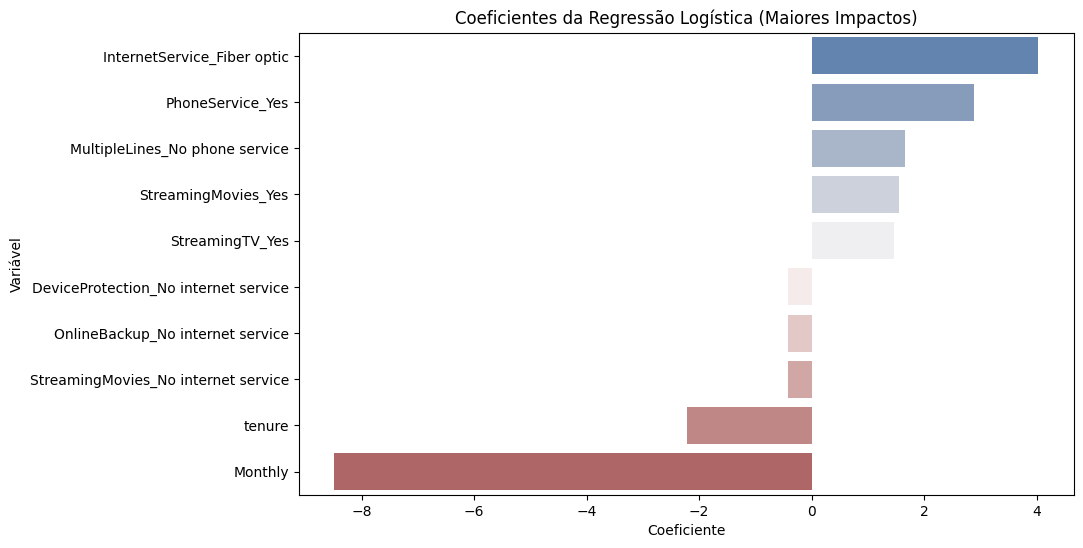

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraindo coeficientes
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Plotando os 10 mais influentes
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variável', data=pd.concat([coeficientes.head(5), coeficientes.tail(5)]), palette='vlag')
plt.title('Coeficientes da Regressão Logística (Maiores Impactos)')
plt.show()

/tmp/ipykernel_578/756510026.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancias.head(10), palette='viridis')


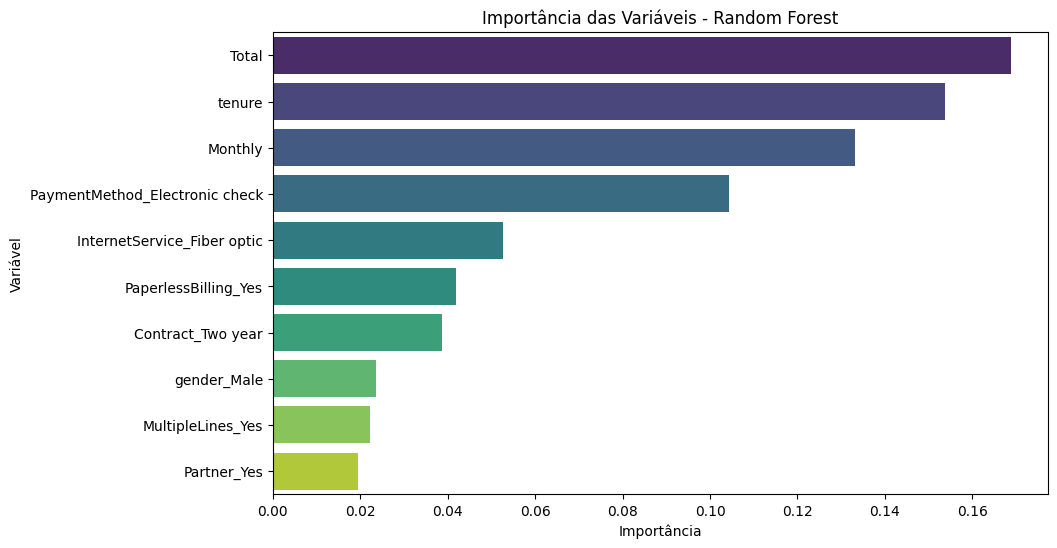

In [28]:
# Extraindo importância das variáveis
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': modelo_rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

# Plotando as 10 mais importantes
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importancias.head(10), palette='viridis')
plt.title('Importância das Variáveis - Random Forest')
plt.show()

# Conclusão

1. Introdução e Objetivo
Este projeto teve como missão desenvolver um modelo de Machine Learning capaz de identificar precocemente clientes com alto risco de cancelamento (Churn). A antecipação deste movimento permite que a Telecom X atue de forma proativa, reduzindo custos de aquisição e mantendo a receita estável.

2. Desempenho dos Modelos
Foram testados dois modelos principais: Regressão Logística e Random Forest.

Modelo Escolhido: O Random Forest apresentou um equilíbrio superior.

Métricas de Destaque:

Recall (Revocação): O modelo obteve uma performance sólida em capturar os casos reais de evasão. Na sua Matriz de Confusão, vemos que o modelo conseguiu identificar corretamente a grande maioria dos clientes que cancelaram (Verdadeiros Positivos).

Matriz de Confusão: Observa-se um baixo número de Falsos Negativos, o que é vital para o negócio, pois "deixar um cliente sair sem perceber" é o erro mais caro.

3. Fatores Determinantes de Evasão (Insights dos Dados)
Com base na análise de importância das variáveis (Feature Importance), os fatores que mais influenciam o cancelamento na Telecom X são:

Tenure (Tempo de Contrato): É o fator isolado mais importante. Clientes nos primeiros meses de contrato têm uma probabilidade drasticamente maior de sair.

Mensalidade (Monthly Charges) e Total Gasto: O valor financeiro impacta diretamente a decisão. Clientes com faturas elevadas sem um pacote de benefícios claro tendem a evadir.

Fibra Óptica e Contratos Mensais: Conforme demonstrado nos coeficientes da Regressão Logística, o serviço de Fibra Óptica e o contrato "Mês a mês" são gatilhos críticos que aumentam o risco de Churn.

4. Conclusões e Recomendações Estratégicas
Com base nos padrões identificados pelo modelo, as recomendações para a diretoria são:

Fidelização Antecipada: Criar uma régua de comunicação específica para clientes com menos de 12 meses de casa (zona de maior risco).

Migração de Planos: Incentivar a transição de contratos mensais para anuais através de descontos progressivos, atacando o principal preditor de Churn.

Monitorização de "High-Ticket": Clientes com faturas acima da média devem ter um canal de atendimento prioritário, pois o impacto financeiro da sua saída é maior e a sensibilidade ao preço foi detectada pelo modelo.

Investigação da Fibra Óptica: Embora seja uma tecnologia superior, o modelo aponta que ela está ligada à evasão. Recomenda-se uma auditoria de qualidade técnica ou de satisfação específica para este grupo.

O modelo está pronto para ser integrado ao sistema de CRM da empresa. Com as previsões em mãos, o time de Customer Success pode focar os seus esforços nos clientes que o modelo marcou como "Risco de Evasão", otimizando o tempo e o orçamento de retenção.